# Pronóstico a 24h de PM2.5 en Pekín — Análisis exploratorio

**Proyecto de Aprendizaje Automático en Series Temporales y Flujos de Datos**

Este cuaderno cubre el **análisis exploratorio de la serie temporal**. Parte del dataset resultante de la fase de preparación (`02_preparacion_datos.ipynb`), exportado como `../data/processed/beijing_data_preparado.csv`: la variable `pm2.5` ya está imputada (huecos de hasta 6 horas) y la dirección del viento codificada en one-hot.

## 1. Carga del dataset preparado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv('../data/processed/beijing_data_preparado.csv', index_col='datetime', parse_dates=True)

# Reconstruimos la dirección del viento como una sola columna categórica para los análisis por grupo
cols_viento = ['viento_NE', 'viento_NW', 'viento_SE', 'viento_cv']
df['cbwd'] = df[cols_viento].idxmax(axis=1).str.replace('viento_', '')

print("Observaciones:", len(df))
print("NaN en pm2.5 (huecos largos no imputados):", df['pm2.5'].isna().sum())
df.head()

Observaciones: 43824
NaN en pm2.5 (huecos largos no imputados): 1463


,pm2.5,pm2.5_imputado,DEWP,TEMP,PRES,Iws,Is,Ir,viento_NE,viento_NW,viento_SE,viento_cv,cbwd
datetime,,,,,,,,,,,,,
2010-01-01 00:00:00,129.0,True,-21,-11.0,1021.0,1.79,0,0,False,True,False,False,NW
2010-01-01 01:00:00,129.0,True,-21,-12.0,1020.0,4.92,0,0,False,True,False,False,NW
2010-01-01 02:00:00,129.0,True,-21,-11.0,1019.0,6.71,0,0,False,True,False,False,NW
2010-01-01 03:00:00,129.0,True,-21,-14.0,1019.0,9.84,0,0,False,True,False,False,NW
2010-01-01 04:00:00,129.0,True,-20,-12.0,1018.0,12.97,0,0,False,True,False,False,NW


Algunas técnicas de este análisis (PACF, test ADF y descomposición estacional) no admiten valores ausentes. Para ellas se usa una copia de la serie en la que **solo los huecos largos que quedan** (≈3,3% de la serie) se completan por interpolación temporal. Esta copia es **exclusivamente exploratoria**: no se utiliza en el modelado, donde esas horas se excluyen, tal y como se decidió en la preparación de datos.

In [2]:
pm25 = df['pm2.5']
pm25_completa = pm25.interpolate(method='time')   # solo para técnicas que exigen serie completa
print("NaN en la copia exploratoria:", pm25_completa.isna().sum())

NaN en la copia exploratoria: 0


## 2. Visión general y distribución

In [3]:
# Estadísticos de la distribución de pm2.5 (sobre valores observados o imputados, sin los huecos largos)
valores = pm25.dropna()
print(f"Media:     {valores.mean():.1f} µg/m³")
print(f"Mediana:   {valores.median():.1f} µg/m³")
print(f"Asimetría: {valores.skew():.2f}")
print(f"Horas > 150 µg/m³ (contaminación intensa, escala china): {(valores > 150).mean()*100:.1f}%")
print(f"Horas > 250 µg/m³ (contaminación severa, escala china):  {(valores > 250).mean()*100:.1f}%")

Media:     98.6 µg/m³
Mediana:   72.0 µg/m³
Asimetría: 1.82
Horas > 150 µg/m³ (contaminación intensa, escala china): 21.5%
Horas > 250 µg/m³ (contaminación severa, escala china):  7.3%


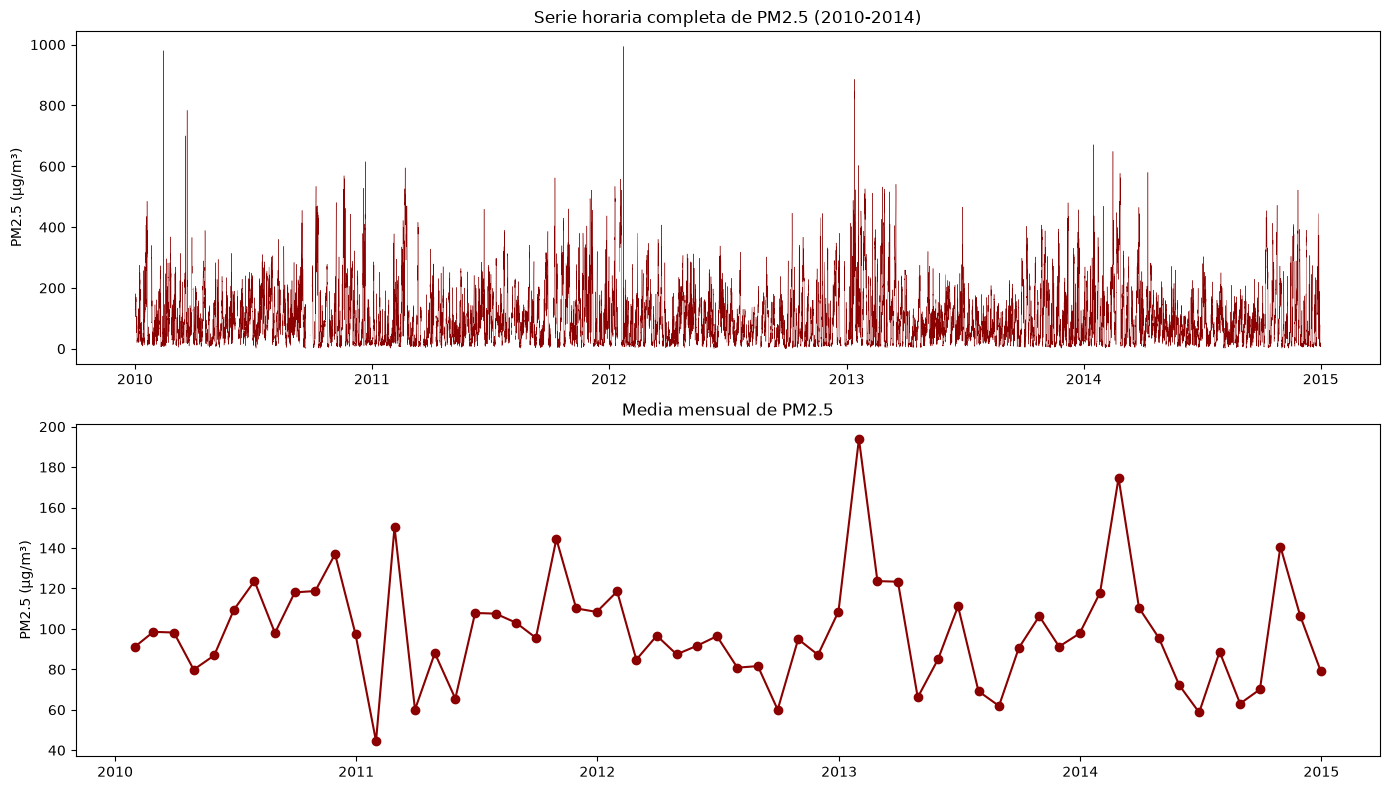

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14,8))
axes[0].plot(df.index, df['pm2.5'], linewidth=0.3, color='darkred')
axes[0].set_title('Serie horaria completa de PM2.5 (2010-2014)')
axes[0].set_ylabel('PM2.5 (µg/m³)')

monthly = df['pm2.5'].resample('ME').mean()
axes[1].plot(monthly.index, monthly.values, marker='o', color='darkred')
axes[1].set_title('Media mensual de PM2.5')
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

**Observación:** la serie es muy ruidosa a nivel horario, con picos puntuales que superan 800-1000 µg/m³ (episodios extremos de contaminación). La media mensual revela una clara componente estacional anual, con picos recurrentes en invierno (probablemente asociados a la calefacción) y valores más bajos en verano.

## 3. Patrones estacionales: hora del día, día de la semana, mes

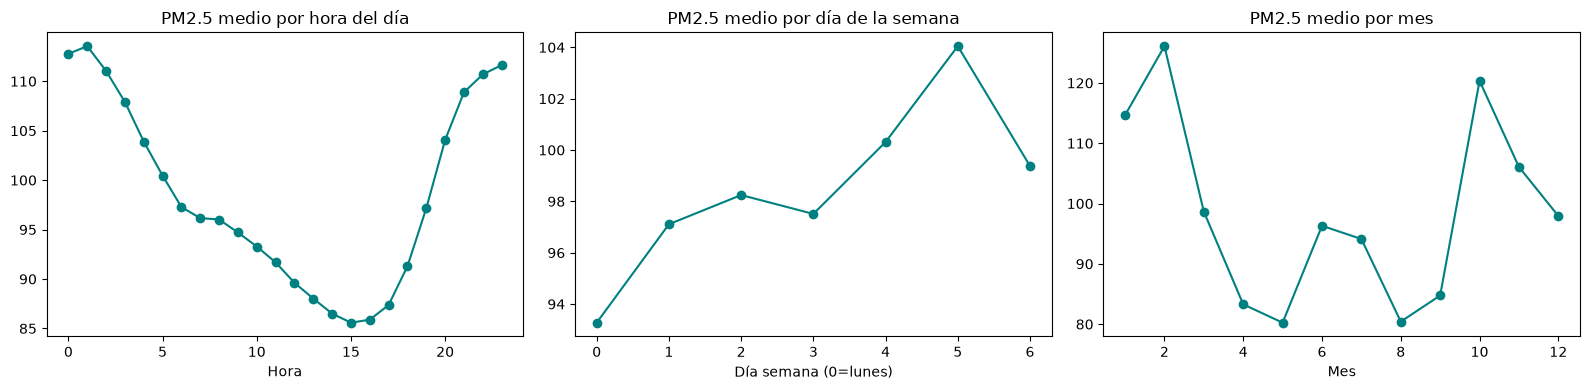

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

df.groupby(df.index.hour)['pm2.5'].mean().plot(ax=axes[0], marker='o', color='teal')
axes[0].set_title('PM2.5 medio por hora del día')
axes[0].set_xlabel('Hora')

df.groupby(df.index.dayofweek)['pm2.5'].mean().plot(ax=axes[1], marker='o', color='teal')
axes[1].set_title('PM2.5 medio por día de la semana')
axes[1].set_xlabel('Día semana (0=lunes)')

df.groupby(df.index.month)['pm2.5'].mean().plot(ax=axes[2], marker='o', color='teal')
axes[2].set_title('PM2.5 medio por mes')
axes[2].set_xlabel('Mes')

plt.tight_layout()
plt.show()

**Observaciones:**
- **Ciclo diario claro**: PM2.5 más alto durante la noche/madrugada (20h-2h) y más bajo a media tarde (14h-16h) — patrón típico ligado a la altura de la capa de mezcla atmosférica (más baja de noche, atrapa contaminantes) y al tráfico/calefacción.
- **Día de la semana**: variación débil, ligero repunte hacia el viernes/sábado.
- **Mes**: estacionalidad anual marcada — valores más altos en meses fríos (enero, febrero, octubre-diciembre) y más bajos en verano (agosto), coherente con el uso de calefacción en Pekín.

## 4. Dependencia temporal: ACF, PACF y estacionariedad

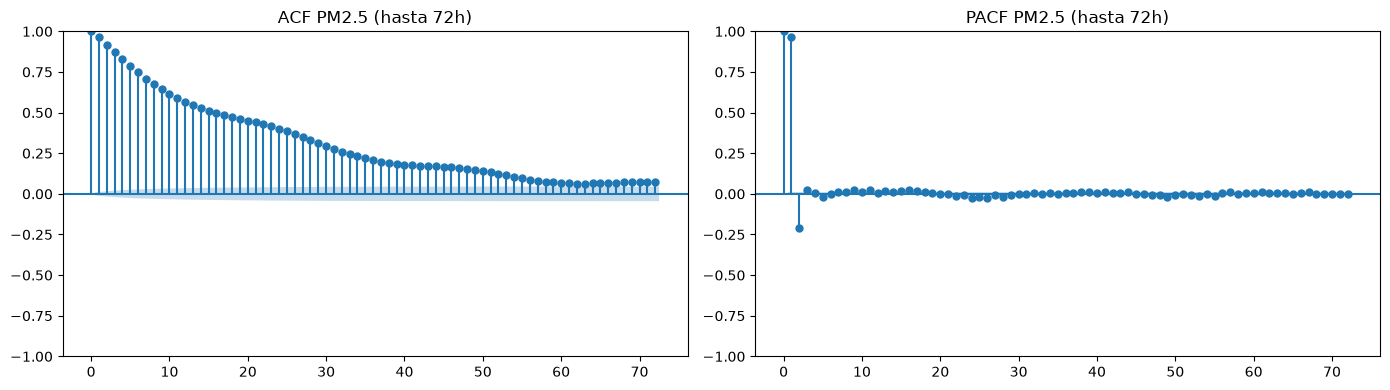

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(pm25_completa, lags=72, ax=axes[0])
axes[0].set_title('ACF PM2.5 (hasta 72h)')
plot_pacf(pm25_completa, lags=72, ax=axes[1], method='ywm')
axes[1].set_title('PACF PM2.5 (hasta 72h)')
plt.tight_layout()
plt.show()

**Observación:** la ACF decae de forma lenta y sostenida (alta persistencia, memoria larga), mientras que la PACF cae bruscamente tras el lag 1-2. Esto sugiere una fuerte componente autorregresiva de corto plazo, pero con dependencia acumulada a más largo plazo — relevante de cara a elegir qué lags incluir como features y a valorar modelos con componente estacional (24h, posiblemente semanal).

In [7]:
adf_result = adfuller(pm25_completa)
print("Estadístico ADF:", adf_result[0])
print("p-valor:", adf_result[1])

Estadístico ADF: -21.39567212588591
p-valor: 0.0


/var/folders/x4/8jkn_8w16nd433x2wgqby3bw0000gn/T/ipykernel_6248/3707089494.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(pm25_completa)


**Observación:** el test ADF rechaza claramente la hipótesis de raíz unitaria (p-valor ≈ 0). Con un tamaño muestral tan grande (~44.000 observaciones) el test tiene mucha potencia estadística, así que este resultado debe interpretarse con cautela: la serie no tiene una tendencia estocástica de largo plazo, pero sí conserva la fuerte autocorrelación de corto plazo observada en la ACF/PACF.

## 5. Relación con variables meteorológicas exógenas

In [8]:
corr_df = df[['pm2.5','DEWP','TEMP','PRES','Iws','Is','Ir']]
corr_df.corr()['pm2.5'].sort_values(ascending=False)

pm2.5    1.000000
DEWP     0.170572
Is       0.019167
PRES    -0.046899
Ir      -0.050680
TEMP    -0.091063
Iws     -0.246948
Name: pm2.5, dtype: float64

In [9]:
df.groupby('cbwd')['pm2.5'].mean().sort_values(ascending=False)

cbwd
cv    125.980824
SE    110.806632
NE     89.981995
NW     70.098762
Name: pm2.5, dtype: float64

**Observaciones:**
- **Iws (viento acumulado)** tiene la correlación más fuerte, negativa (≈ -0.25): a más viento, menor concentración de partículas — tiene sentido físico (dispersión de contaminantes).
- **DEWP (punto de rocío)** correlación positiva débil (≈ 0.17).
- **TEMP, PRES, Ir** correlaciones débiles.
- **cbwd (dirección de viento)** muestra un efecto claro pese a ser categórica: los vientos del **NW** (que en Pekín suelen venir de zonas menos industrializadas) se asocian a la menor PM2.5 media (~70 µg/m³), mientras que el viento **calmo/variable (cv)** se asocia a la mayor concentración (~126 µg/m³) — el aire estancado no dispersa los contaminantes. Esto sugiere que `cbwd` aporta información relevante y debe codificarse adecuadamente (no descartarse por ser categórica).

## 6. Descomposición estacional (tendencia / estacionalidad diaria / residuo)

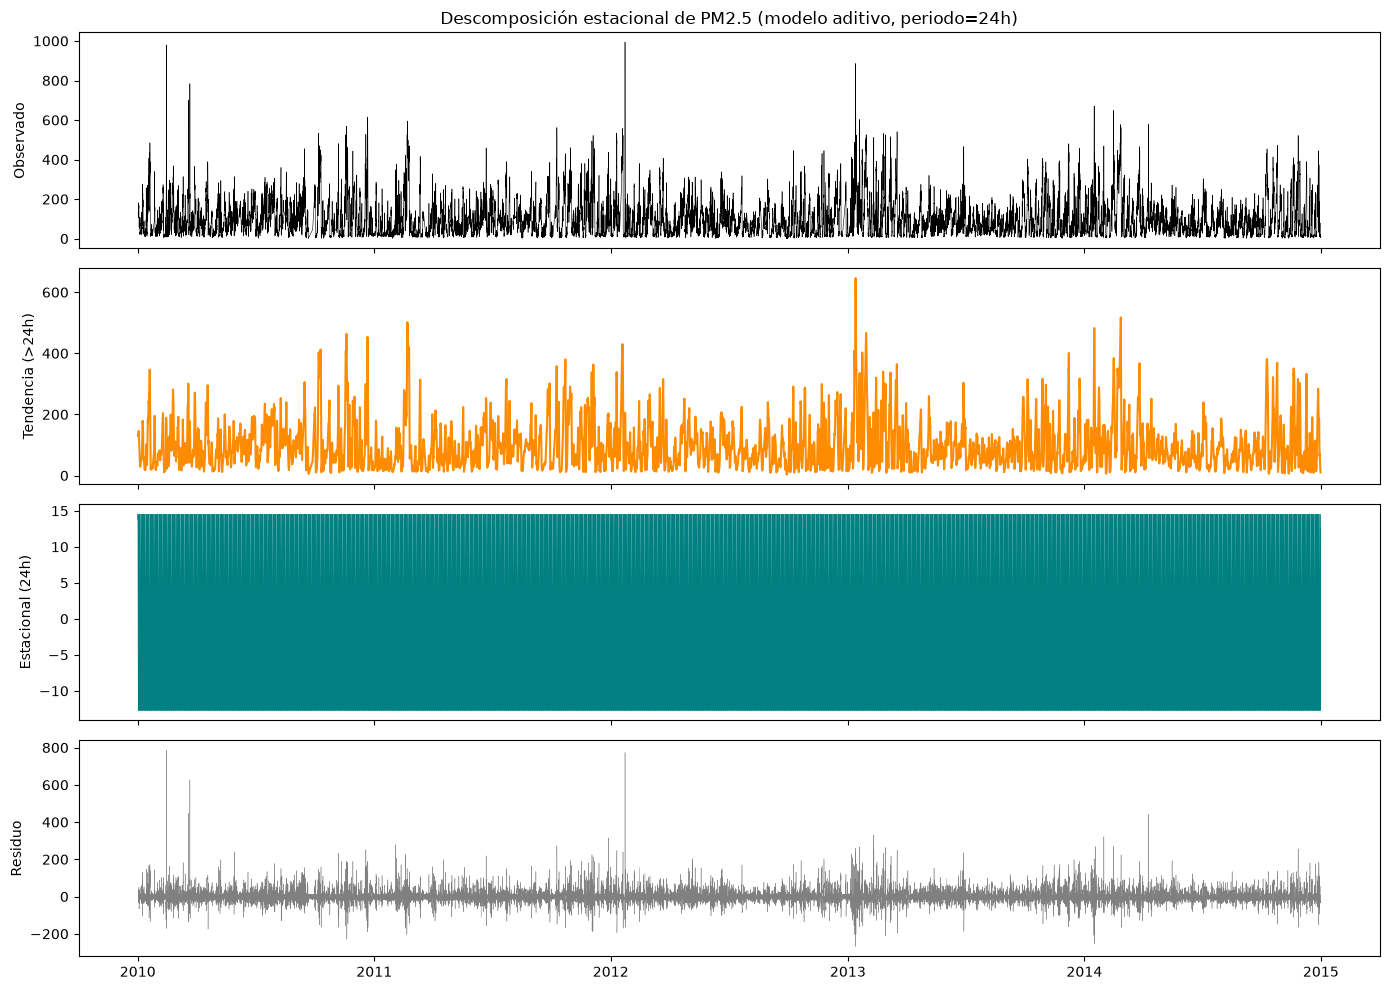

Ratio Var(residuo)/Var(observado): 0.18199692569476805


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(pm25_completa, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14,10), sharex=True)
axes[0].plot(pm25_completa.index, decomposition.observed, linewidth=0.4, color='black')
axes[0].set_ylabel('Observado')
axes[1].plot(pm25_completa.index, decomposition.trend, color='darkorange')
axes[1].set_ylabel('Tendencia (>24h)')
axes[2].plot(pm25_completa.index, decomposition.seasonal, linewidth=0.3, color='teal')
axes[2].set_ylabel('Estacional (24h)')
axes[3].plot(pm25_completa.index, decomposition.resid, linewidth=0.3, color='gray')
axes[3].set_ylabel('Residuo')
axes[0].set_title('Descomposición estacional de PM2.5 (modelo aditivo, periodo=24h)')
plt.tight_layout()
plt.show()

resid_valid = decomposition.resid.dropna()
obs_valid = decomposition.observed.reindex(resid_valid.index)
print("Ratio Var(residuo)/Var(observado):", resid_valid.var() / obs_valid.var())

**Observación:** con `seasonal_decompose` (modelo aditivo, periodo=24h) la componente de "tendencia" se calcula mediante una media móvil centrada de 24 horas, por lo que no representa una tendencia secular, sino la evolución de baja frecuencia (multi-día) de la serie — captura los episodios de contaminación que duran varios días. A diferencia de STL, `seasonal_decompose` asume que el patrón estacional es **fijo** a lo largo de toda la serie (se calcula como un único perfil diario promedio repetido), por lo que no puede reflejar que la amplitud del ciclo diario varía según el nivel de contaminación de fondo — esta es una limitación conocida del método frente a alternativas más flexibles. Aun así, el resultado es útil como primera aproximación: el residuo conserva una parte relevante de la varianza total, lo que indica que hay bastante variabilidad de corto plazo (probablemente ligada a eventos puntuales) que ni la tendencia ni el ciclo diario medio explican por sí solos — es la parte que los modelos con exógenas y lags cortos deberían intentar capturar.

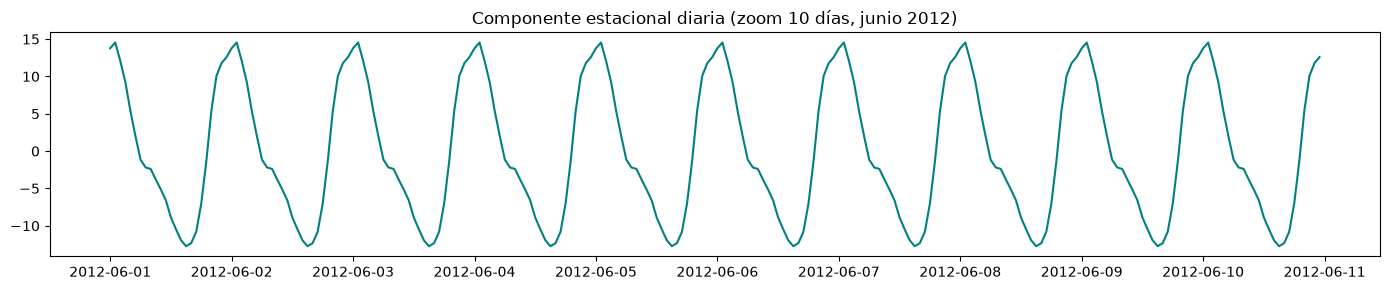

In [11]:
fig, ax = plt.subplots(figsize=(14,3))
zoom = decomposition.seasonal['2012-06-01':'2012-06-10']
ax.plot(zoom.index, zoom.values, color='teal')
ax.set_title('Componente estacional diaria (zoom 10 días, junio 2012)')
plt.tight_layout()
plt.show()

## 7. Relación con retardo (lead-lag) entre exógenas y PM2.5

No basta con mirar la correlación contemporánea (lag=0): interesa saber si una exógena **anticipa** cambios futuros en PM2.5, ya que eso justificaría incluirla con un lag concreto como feature para el pronóstico a 24h. Calculamos `corr(exógena_t, PM2.5_{t+lag})` para lags de -48 a +48 horas (lag positivo = la exógena en el pasado predice PM2.5 en el futuro).

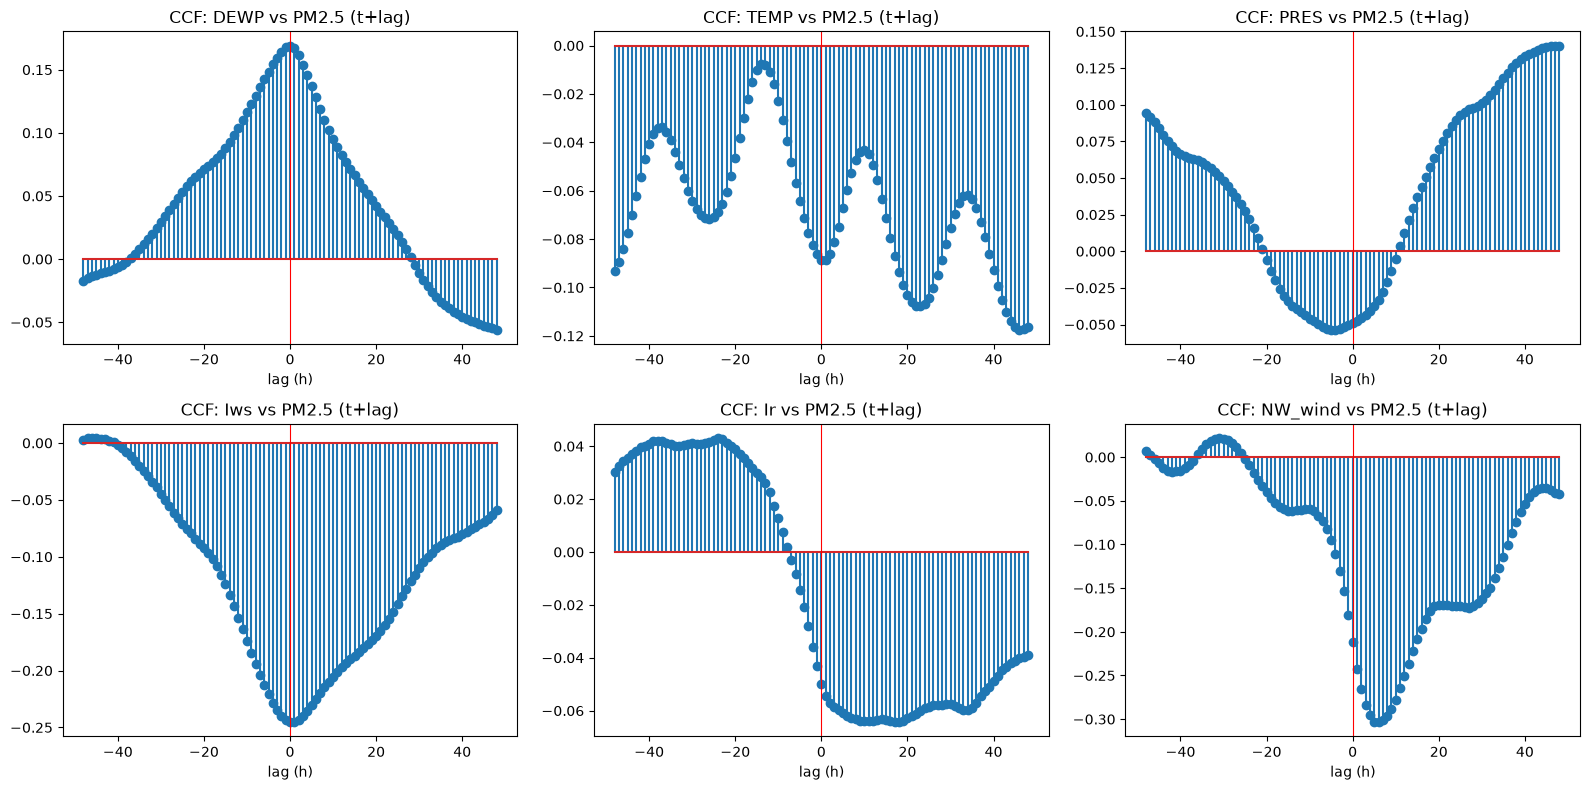

DEWP: lag con |corr| máxima = 0h, corr = 0.169
TEMP: lag con |corr| máxima = 46h, corr = -0.117
PRES: lag con |corr| máxima = 47h, corr = 0.140
Iws: lag con |corr| máxima = 0h, corr = -0.245
Ir: lag con |corr| máxima = 18h, corr = -0.064
NW_wind: lag con |corr| máxima = 6h, corr = -0.304


In [12]:
def ccf_leadlag(x, y, max_lag=48):
    lags = range(-max_lag, max_lag + 1)
    vals = []
    for lag in lags:
        shifted_y = y.shift(-lag)
        common = x.index.intersection(shifted_y.dropna().index)
        vals.append(x.reindex(common).corr(shifted_y.reindex(common)))
    return list(lags), vals

exogs = {
    'DEWP': df['DEWP'],
    'TEMP': df['TEMP'],
    'PRES': df['PRES'],
    'Iws': df['Iws'],
    'Ir': df['Ir'],
    'NW_wind': df['viento_NW'].astype(int),
}

fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()
best_lags = {}
for i, (name, series) in enumerate(exogs.items()):
    lags, vals = ccf_leadlag(series, pm25_completa, max_lag=48)
    axes[i].stem(lags, vals)
    axes[i].axvline(0, color='red', linewidth=0.8)
    axes[i].set_title(f'CCF: {name} vs PM2.5 (t+lag)')
    axes[i].set_xlabel('lag (h)')
    best_idx = np.argmax(np.abs(vals))
    best_lags[name] = (lags[best_idx], vals[best_idx])

plt.tight_layout()
plt.show()

for k, v in best_lags.items():
    print(f"{k}: lag con |corr| máxima = {v[0]}h, corr = {v[1]:.3f}")

**Observaciones clave:**
- **`NW_wind` es el hallazgo más útil**: la correlación negativa es más fuerte en **lag ≈ 6h** (-0.30) que en lag 0 (-0.28) — es decir, que sople viento del NW *ahora* predice PM2.5 más bajo **varias horas después**, con un efecto que se mantiene hasta ~20h. Es un indicador adelantado genuino y un candidato claro para incluir como feature con lags de varias horas.
- **`Iws`** tiene su correlación más fuerte en lag 0 (contemporánea): el efecto de dispersión por viento es prácticamente inmediato, no anticipado.
- **`Ir` (lluvia)** muestra el patrón opuesto a `NW_wind`: correlación casi nula en lags negativos y negativa a partir de lag 0-5h — la lluvia "lava" la contaminación poco después de empezar, no antes.
- **`TEMP`** muestra un patrón oscilante en vez de un pico claro — esto es un artefacto de que ambas series comparten el ciclo diario (aliasing), no una relación causal de lead-lag genuina. Hay que tener cuidado de no interpretar ese patrón como una señal predictiva real.
- **`PRES` y `DEWP`** muestran máximos suaves cerca de lag 0 que se extienden varias horas en ambas direcciones — reflejan que son variables de evolución lenta (sistemas meteorológicos de varios días), no relaciones de anticipación concretas y accionables como la de `NW_wind`.

**Implicación para feature engineering:** además de los lags "obvios" de la propia serie de PM2.5, tiene sentido incluir `NW_wind` (y quizás la dirección de viento en general) con un lag de varias horas como predictor explícito, ya que aporta información que el valor contemporáneo por sí solo no captura del todo.

## 8. Próximos pasos

- Construcción de variables de retardo (lags 1, 2 y 24 de `pm2.5`; `viento_NW` con retardo de varias horas) y de calendario (hora, mes), respetando siempre el orden temporal.
- Partición cronológica train/validación/test y esquema de backtesting para el horizonte de 24h.
- Definición de los baselines antes de pasar a modelos más complejos.